<a href="https://colab.research.google.com/github/vishal6975/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vishal6975/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
# W07 SETUP — Load data and train the same Logistic Regression model

import duckdb
import os
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# Connect to DuckDB
con = duckdb.connect()
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

# Get Hugging Face token from Colab Secrets
try:
    from google.colab import userdata
    token = userdata.get("HF_TOKEN")
    os.environ["HF_TOKEN"] = token
    print("HF_TOKEN loaded successfully.")
except Exception as e:
    token = os.environ.get("HF_TOKEN")

if not token:
    raise RuntimeError(
        "HF_TOKEN not found. Add HF_TOKEN in Colab Secrets."
    )

# Create Hugging Face secret
con.execute(f"""
CREATE OR REPLACE SECRET hf_token (
    TYPE huggingface,
    TOKEN '{token}'
);
""")

# March 2026 dataset
path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/"
    "month=2026-03/*.parquet"
)

# Load data
df = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,
    report_date,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position
FROM read_parquet('{path}')
""").df()

# Calculate CTR
df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    np.nan
)

# Early March = model features
early = df[df.report_date <= "2026-03-15"].groupby(
    ["client_hash_id", "content_hash_id"]
).agg(
    impressions_early=("gsc_impressions", "sum"),
    clicks_early=("gsc_clicks", "sum"),
    ctr_early=("ctr", "mean"),
    avg_position_early=("gsc_avg_position", "mean")
).reset_index()

# Late March = future outcome
late = df[df.report_date >= "2026-03-16"].groupby(
    ["client_hash_id", "content_hash_id"]
).agg(
    ctr_late=("ctr", "mean")
).reset_index()

# Combine early and late data
model_df = early.merge(
    late,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

# Target: future CTR decline
model_df["future_ctr_declined"] = (
    model_df["ctr_late"] < model_df["ctr_early"]
).astype(int)

# Features
features = [
    "impressions_early",
    "clicks_early",
    "ctr_early",
    "avg_position_early"
]

X = model_df[features].replace(
    [np.inf, -np.inf],
    np.nan
)

y = model_df["future_ctr_declined"]

# Remove missing values
valid = X.notna().all(axis=1)

X = X[valid]
y = y[valid]

# Train Logistic Regression
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

model.fit(X, y)

# Predictions
pred = model.predict(X)

print("=" * 50)
print("W07 MODEL SETUP COMPLETE")
print("=" * 50)
print("Rows:", len(X))
print("Precision:", round(
    precision_score(y, pred, zero_division=0), 4
))
print("Recall:", round(
    recall_score(y, pred, zero_division=0), 4
))
print("F1:", round(
    f1_score(y, pred, zero_division=0), 4
))

HF_TOKEN loaded successfully.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

W07 MODEL SETUP COMPLETE
Rows: 151980
Precision: 0.7114
Recall: 0.7191
F1: 0.7152


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*




The action queue ranks content by the model's predicted probability of future CTR decline.

Priority is given to content predicted to decline, with higher priority when multiple observed search signals support review.

Reason codes are decision-support labels based on observed model inputs. They do not prove causation.

| Priority | Reason code | Recommended action |
|---|---|---|
| HIGH | MULTI_SIGNAL | Prioritize human review and investigate whether the content should be refreshed |
| MEDIUM | CTR_DECLINE_RISK | Review search performance and consider a content refresh |
| LOW | NO_ACTION | Continue monitoring; no immediate change recommended |

The model is used to prioritize human attention, not to automatically change content.

In [9]:
# Create ranked action queue from the validated model output

import pandas as pd
import numpy as np

# Work from the model_df created in the previous modeling workflow.
# If model_df is already available, reuse it.
required_columns = [
    "client_hash_id",
    "content_hash_id",
    "impressions_early",
    "clicks_early",
    "ctr_early",
    "avg_position_early"
]

missing = [c for c in required_columns if c not in model_df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Use the trained model to calculate decline probability
X_action = model_df[
    [
        "impressions_early",
        "clicks_early",
        "ctr_early",
        "avg_position_early"
    ]
].replace([np.inf, -np.inf], np.nan)

valid_action = X_action.notna().all(axis=1)

action_queue = model_df.loc[valid_action].copy()

action_queue["decline_probability"] = model.predict_proba(
    X_action.loc[valid_action]
)[:, 1]

action_queue["predicted_decline"] = model.predict(
    X_action.loc[valid_action]
)

# Median-based supporting signals
imp_median = action_queue["impressions_early"].median()
position_median = action_queue["avg_position_early"].median()

def get_reason(row):
    signals = []

    if row["predicted_decline"] == 1:
        signals.append("CTR_DECLINE_RISK")

    if row["impressions_early"] <= imp_median:
        signals.append("LOW_SEARCH_SIGNAL")

    if row["avg_position_early"] >= position_median:
        signals.append("POSITION_SIGNAL")

    if row["predicted_decline"] == 1 and len(signals) >= 2:
        return "MULTI_SIGNAL"

    if row["predicted_decline"] == 1:
        return "CTR_DECLINE_RISK"

    return "NO_ACTION"


action_queue["reason_code"] = action_queue.apply(
    get_reason,
    axis=1
)

def get_priority(row):
    if row["reason_code"] == "MULTI_SIGNAL":
        return "HIGH"
    elif row["reason_code"] == "CTR_DECLINE_RISK":
        return "MEDIUM"
    return "LOW"


action_queue["priority"] = action_queue.apply(
    get_priority,
    axis=1
)

# Rank highest predicted risk first
priority_order = {
    "HIGH": 0,
    "MEDIUM": 1,
    "LOW": 2
}

action_queue["priority_order"] = action_queue["priority"].map(
    priority_order
)

action_queue = action_queue.sort_values(
    ["priority_order", "decline_probability"],
    ascending=[True, False]
).reset_index(drop=True)

action_queue["rank"] = np.arange(1, len(action_queue) + 1)

print("Ranked action queue created.")
print("Rows:", len(action_queue))
print()
print(
    action_queue[
        [
            "rank",
            "content_hash_id",
            "decline_probability",
            "predicted_decline",
            "reason_code",
            "priority"
        ]
    ].head(10)
)

Ranked action queue created.
Rows: 151980

   rank           content_hash_id  decline_probability  predicted_decline  \
0     1  content_17dac109f764bd2c                  1.0                  1   
1     2  content_2c244ac41fd49e60                  1.0                  1   
2     3  content_368eab3cb9324cec                  1.0                  1   
3     4  content_5b0bd44b9344a6b3                  1.0                  1   
4     5  content_5dec5960f6901d82                  1.0                  1   
5     6  content_65cdd7595809aef6                  1.0                  1   
6     7  content_827288f0898e2001                  1.0                  1   
7     8  content_9a1742d36e4b82b8                  1.0                  1   
8     9  content_a97a423a8e706780                  1.0                  1   
9    10  content_d72c255f692bfe50                  1.0                  1   

    reason_code priority  
0  MULTI_SIGNAL     HIGH  
1  MULTI_SIGNAL     HIGH  
2  MULTI_SIGNAL     HIGH  
3

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



This playbook is intended for content teams and analysts who need to prioritize pages for human review.

The model can help identify content with a higher predicted probability of future CTR decline and organize review using ranked priorities and reason codes.

The output is decision-support, not an automatic content decision.

The model was developed using March 2026 search-performance observations and uses early-period impressions, clicks, CTR, and average position as inputs.

The reported F1 score from the modeling notebook was 0.7152, but this was measured on the same data used for model fitting. Therefore, it should be treated as an in-sample model result rather than a held-out validation score.

The model does not establish that any input caused CTR decline. CTR can also change because of search intent, SERP features, competition, ranking changes, seasonality, and normal variation.

The model should not be treated as production-ready without further time-aware validation and monitoring.

In [10]:
# Basic checks for intended use and limits

print("Intended use: human-reviewed content prioritization")
print("Model type: Logistic Regression")
print("Target: future CTR decline")
print("Evaluation rows in W05:", len(X))
print("Reported W05 F1:", round(f1_score(y, pred, zero_division=0), 4))

assert "decline_probability" in action_queue.columns
assert "reason_code" in action_queue.columns
assert "priority" in action_queue.columns

print("Decision-support fields are present.")

Intended use: human-reviewed content prioritization
Model type: Logistic Regression
Target: future CTR decline
Evaluation rows in W05: 151980
Reported W05 F1: 0.7152
Decision-support fields are present.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



Every recommended action must be reviewed by a human before implementation.

The reviewer should check:

1. The predicted decline probability and priority.
2. The underlying impressions, clicks, CTR, and average position.
3. Search intent and current SERP context.
4. Whether the content is still relevant and useful.
5. Whether a refresh is actually justified.
6. Whether the recommendation should be accepted, modified, or rejected.

### No-go automation cases

The model should never automatically:

- publish content;
- delete content;
- substantially rewrite content;
- change important SEO or business strategy;
- override editorial judgment;
- treat a prediction as proof of poor content quality;
- make decisions outside the observed data conditions without human review.

The model's role is to prioritize investigation. Final content decisions remain with a human.

In [11]:
# Human-review safety check

no_go_actions = [
    "automatic_publish",
    "automatic_delete",
    "automatic_rewrite",
    "automatic_strategy_change"
]

print("Human review required:", True)
print("No-go automated actions:")

for action in no_go_actions:
    print("-", action)

print("\nFinal decision remains with a human reviewer.")


Human review required: True
No-go automated actions:
- automatic_publish
- automatic_delete
- automatic_rewrite
- automatic_strategy_change

Final decision remains with a human reviewer.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



The recommendations should be monitored because search behavior and content performance can change over time.

The following signals should be reviewed:

- precision and recall;
- F1 score;
- false positives and false negatives;
- distribution of predicted decline probabilities;
- changes in impressions, clicks, CTR, and average position;
- changes in the types of content being scored;
- frequency of human disagreement with recommendations.

A review should be triggered if model performance consistently becomes weaker than the previously measured result, if the input data changes substantially, or if reviewers frequently reject the recommendations.

Retraining or revalidation should use newer time periods and a time-aware evaluation. The updated model should be compared with the existing approach before being adopted.

No fixed production retraining threshold is claimed here because the current notebook does not establish one.

The current model is therefore treated as a research and decision-support workflow rather than a production monitoring system.

In [12]:
# Monitoring snapshot

print("MONITORING SNAPSHOT")
print("=" * 40)

print("Current action queue rows:", len(action_queue))

print("\nPriority distribution:")
print(action_queue["priority"].value_counts())

print("\nReason-code distribution:")
print(action_queue["reason_code"].value_counts())

print("\nPredicted decline rate:",
      round(action_queue["predicted_decline"].mean(), 4))

print("\nMonitoring recommendation:")
print("Re-evaluate performance on a newer time period before production use.")

MONITORING SNAPSHOT
Current action queue rows: 151980

Priority distribution:
priority
LOW       115907
MEDIUM     21990
HIGH       14083
Name: count, dtype: int64

Reason-code distribution:
reason_code
NO_ACTION           115907
CTR_DECLINE_RISK     21990
MULTI_SIGNAL         14083
Name: count, dtype: int64

Predicted decline rate: 0.2374

Monitoring recommendation:
Re-evaluate performance on a newer time period before production use.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*



The ranked action queue is exported to `work/outputs/` so that the research paper can reuse the same recommendations generated by this notebook.

The queue contains the ranking, predicted decline probability, priority, reason code, and observed search-performance signals used for review.

The CSV is intentionally treated as a generated output rather than a committed data file.

A reusable summary figure is also exported to `work/figures/`.

Queue exported to: work/outputs/ranked_action_queue.csv
Queue rows: 151980


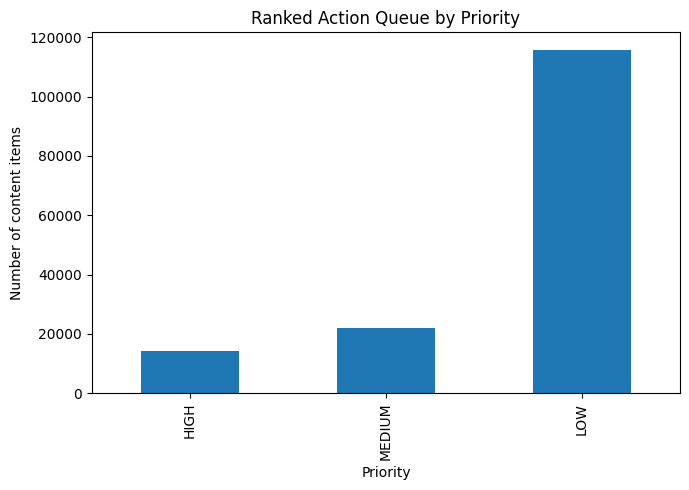

Figure exported to: work/figures/action_queue_priority.png


In [13]:
# Export ranked action queue

import os
import matplotlib.pyplot as plt

output_dir = "work/outputs"
figure_dir = "work/figures"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(figure_dir, exist_ok=True)

export_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "decline_probability",
    "predicted_decline",
    "reason_code",
    "priority",
    "impressions_early",
    "clicks_early",
    "ctr_early",
    "avg_position_early"
]

ranked_queue = action_queue[export_columns].copy()

queue_path = os.path.join(
    output_dir,
    "ranked_action_queue.csv"
)

ranked_queue.to_csv(
    queue_path,
    index=False
)

print("Queue exported to:", queue_path)
print("Queue rows:", len(ranked_queue))


# Create reusable figure

priority_counts = (
    ranked_queue["priority"]
    .value_counts()
    .reindex(["HIGH", "MEDIUM", "LOW"])
    .fillna(0)
)

plt.figure(figsize=(7, 5))
priority_counts.plot(kind="bar")
plt.title("Ranked Action Queue by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of content items")
plt.tight_layout()

figure_path = os.path.join(
    figure_dir,
    "action_queue_priority.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure exported to:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.